In [1]:
import pandas as pd

CSV_PATH = "/home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/data/combined_output_data_points.csv"


def read_csv_and_get_columns(path: str):
    """
    Read the CSV file and return:
    - the DataFrame
    - the list of column names
    """
    df = pd.read_csv(path, low_memory=False)
    columns = df.columns.tolist()
    return df, columns
df, cols = read_csv_and_get_columns(CSV_PATH)

print("Columns:")
print(cols)


Columns:
['id', 'lat', 'lon', 'property', 'original_name', 'upper_depth_cm', 'lower_depth_cm', 'value', 'unit', 'sampling_date', 'license', 'h3_index', 'publication_date', 'data_source']


In [2]:
import pandas as pd
import geopandas as gpd

def add_country_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add 'country' and 'continent' columns using spatial join.
    Requires lat and lon columns.
    """

    if "lat" not in df.columns or "lon" not in df.columns:
        raise ValueError("Dataset must contain 'lat' and 'lon' columns.")

    # Load Natural Earth countries (from official URL)
    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(url)

    world = world[["geometry", "ADMIN", "CONTINENT"]]
    world = world.rename(columns={
        "ADMIN": "country",
        "CONTINENT": "continent"
    })

    # Convert points to GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"
    )

    # Spatial join
    joined = gpd.sjoin(gdf, world, how="left", predicate="within")

    joined["country"] = joined["country"].fillna("Unknown")
    joined["continent"] = joined["continent"].fillna("Unknown")

    return pd.DataFrame(
        joined.drop(columns=["geometry", "index_right"], errors="ignore")
    )


def get_dataframe_by_country(df: pd.DataFrame, country_name: str) -> pd.DataFrame:
    """
    Case-insensitive country filtering.
    Example: 'brazil' will match 'Brazil'
    """

    if "country" not in df.columns:
        raise ValueError("DataFrame does not contain 'country' column.")

    return df[df["country"].str.lower() == country_name.lower()].copy()

df = add_country_column(df)

print("Columns after enrichment:")
print(df.columns.tolist())


Columns after enrichment:
['id', 'lat', 'lon', 'property', 'original_name', 'upper_depth_cm', 'lower_depth_cm', 'value', 'unit', 'sampling_date', 'license', 'h3_index', 'publication_date', 'data_source', 'country', 'continent']


In [ ]:
records_by_country = (
    df
    .groupby("country")
    .size()
    .reset_index(name="record_count")
    .sort_values("record_count", ascending=False)
)
print(records_by_country)
df.shape


        country  record_count
4       Belgium        324090
62  Switzerland        179381
37       Mexico        127739
21       France         90198
25      Hungary         87593
..          ...           ...
10     Cambodia            51
48     Paraguay            40
19      Estonia            26
8        Brunei             8
38      Moldova             2

[71 rows x 2 columns]


(1278483, 16)

In [7]:
total_records = len(df)
records_by_country["percentage"] = (
    records_by_country["record_count"] / total_records * 100
).round(2)

print(records_by_country.head(10).to_string(index=False))

    country  record_count  percentage
    Belgium        324090       25.35
Switzerland        179381       14.03
     Mexico        127739        9.99
     France         90198        7.06
    Hungary         87593        6.85
Netherlands         50102        3.92
      Spain         30198        2.36
  Argentina         28911        2.26
    Czechia         27926        2.18
     Poland         27551        2.15


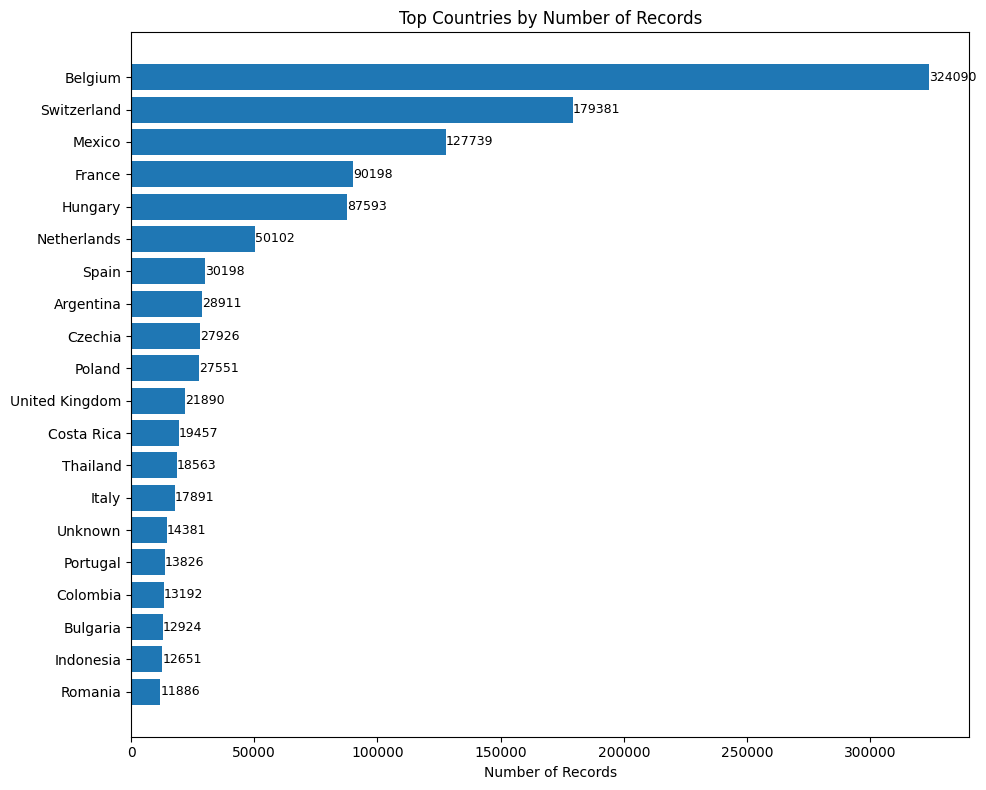

In [11]:
import matplotlib.pyplot as plt

top_n = 20
top_countries = records_by_country.head(top_n)

plt.figure(figsize=(10, 8))

bars = plt.barh(
    top_countries["country"],
    top_countries["record_count"]
)

plt.xlabel("Number of Records")
plt.title("Top Countries by Number of Records")
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,                      
        bar.get_y() + bar.get_height()/2,  
        f'{int(width)}',            
        va='center',                
        ha='left',                  
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [29]:
top_5_countries = (
    records_by_country
    .head(5)["country"]
    .tolist()
)

print("Top 5 countries:", top_5_countries)
df_top5 = df[df["country"].isin(top_5_countries)].copy()
records_by_feature = (
    df_top5
    .groupby("property")
    .size()
    .reset_index(name="record_count")
    .sort_values("record_count", ascending=False)
)

print(records_by_feature)

Top 5 countries: ['Belgium', 'Switzerland', 'Mexico', 'France', 'Hungary']
          property  record_count
17              pH        218589
14            clay        145983
4            CaCO3        138935
19            silt         71071
18            sand         70564
16             occ         45184
2               CF         39140
5               EC         21713
0               BD         18969
10               P         12589
1              CEC         10417
11              TC          8174
15        nematode          4151
8                N          2279
12  WR_gravimetric           347
7               Mg           256
3               Ca           254
9               Na           194
6                K           168
13   WR_volumetric            24


In [30]:
records_country_feature = (
    df_top5
    .groupby(["country", "property"])
    .size()
    .reset_index(name="record_count")
    .sort_values(["country", "record_count"], ascending=[True, False])
)

print(records_country_feature)

        country  property  record_count
16      Belgium        pH        150204
4       Belgium     CaCO3         75766
13      Belgium      clay         72768
0       Belgium        BD          9876
15      Belgium       occ          9154
..          ...       ...           ...
72  Switzerland       CEC           119
75  Switzerland         P            90
76  Switzerland        TC            67
71  Switzerland        BD            18
78  Switzerland  nematode            14

[83 rows x 3 columns]


In [31]:
pivot = (
    records_country_feature
    .pivot(index="country", columns="property", values="record_count")
    .fillna(0)
    .astype(int)
)

print(pivot)

property       BD   CEC     CF   Ca  CaCO3     EC    K   Mg    N   Na      P  \
country                                                                        
Belgium      9876   358   3796   12  75766     50   14   24  310   10    138   
France        220  8830    506   22   9813    122   14   24  850   20  12209   
Hungary      8512   830    236  220   6730    588  140  208  974  164      0   
Mexico        343   280    228    0   7442  20953    0    0  145    0    152   
Switzerland    18   119  34374    0  39184      0    0    0    0    0     90   

property       TC  WR_gravimetric  WR_volumetric   clay  nematode    occ  \
country                                                                    
Belgium       102              20              0  72768        14   9154   
France       1801              18             24  11265      4109   9410   
Hungary      6010              52              0  10755        14  10479   
Mexico        194             257              0  20712    

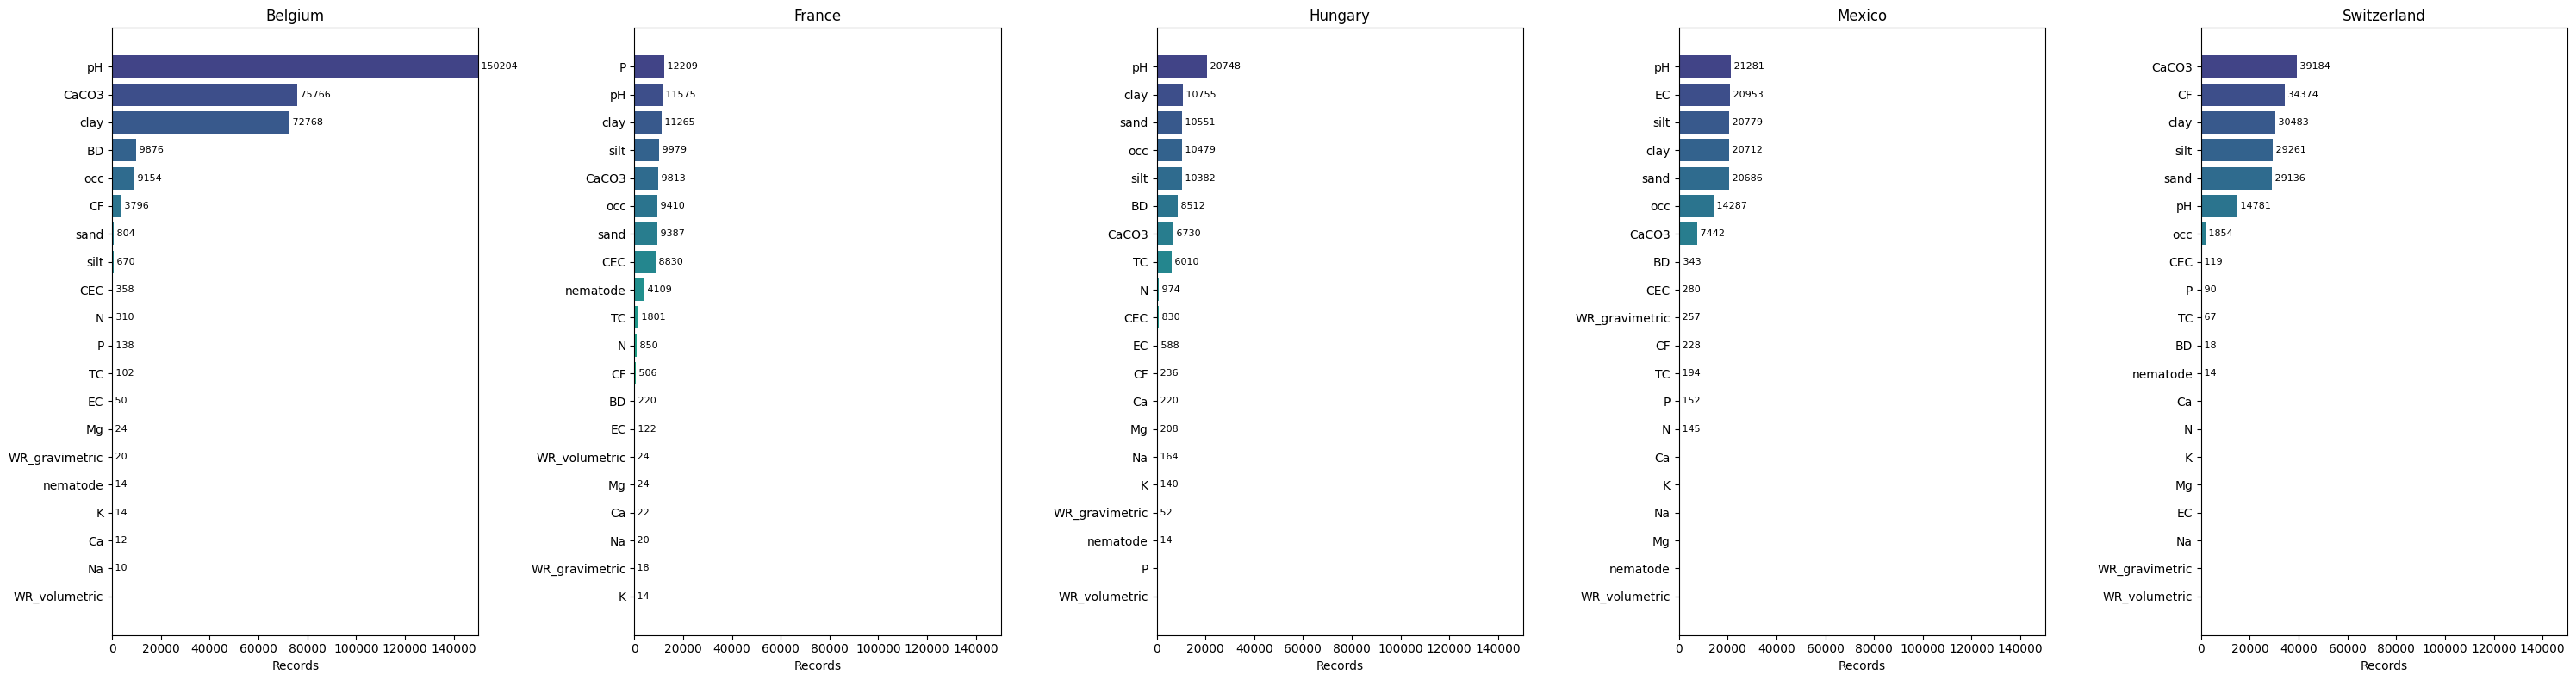

In [33]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

pivot = (
    df_top5
    .groupby(["country", "property"])
    .size()
    .unstack(fill_value=0)
)

countries = pivot.index.tolist()
global_max = pivot.values.max()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(countries),
    figsize=(6 * len(countries), 8),
    sharey=False
)

if len(countries) == 1:
    axes = [axes]

for ax, country in zip(axes, countries):

    values = pivot.loc[country].sort_values(ascending=False)

    colors = cm.viridis(np.linspace(0.2, 0.9, len(values)))

    bars = ax.barh(
        values.index,
        values.values,
        color=colors
    )

    ax.set_title(country)
    ax.set_xlabel("Records")
    ax.set_xlim(0, global_max)  
    ax.invert_yaxis()

    for i, v in enumerate(values.values):
        if v > 0:
            ax.text(
                v,
                i,
                f" {int(v)}",
                va='center',
                fontsize=8
            )

plt.tight_layout()
plt.show()

In [4]:
df_2000 = df[df["sampling_date"] >= 2000]
print(f"Number of records from 2000 onwards: {len(df_2000)}")

Number of records from 2000 onwards: 195426


In [ ]:
df_after_2000 = df[df["year"] >= 2000]

records_by_country = (
    df_after_2000
    .groupby("country")
    .size()
    .reset_index(name="record_count")
    .sort_values("record_count", ascending=False)
)

print(records_by_country)